pygame 2.6.1 (SDL 2.28.4, Python 3.13.1)
Hello from the pygame community. https://www.pygame.org/contribute.html
Starting Minimax Game...
AI (Minimax) Move 1: Time taken: 0.6693s, Nodes expanded: 3781, Depth: 4
AI (Minimax) Move 2: Time taken: 1.0940s, Nodes expanded: 5461, Depth: 4
AI (Minimax) Move 3: Time taken: 1.4889s, Nodes expanded: 5278, Depth: 4
AI (Minimax) Move 4: Time taken: 1.3180s, Nodes expanded: 3980, Depth: 4
AI (Minimax) Move 5: Time taken: 1.1171s, Nodes expanded: 3677, Depth: 4
AI (Minimax) Move 6: Time taken: 0.3789s, Nodes expanded: 1324, Depth: 4
AI (Minimax) Move 7: Time taken: 0.4493s, Nodes expanded: 1766, Depth: 4
AI (Minimax) Move 8: Time taken: 0.7686s, Nodes expanded: 2647, Depth: 4
AI (Minimax) Move 9: Time taken: 1.0321s, Nodes expanded: 3180, Depth: 4
AI (Minimax) Move 10: Time taken: 1.9400s, Nodes expanded: 5910, Depth: 4
AI (Minimax) Move 11: Time taken: 2.7388s, Nodes expanded: 8306, Depth: 4
AI (Minimax) Move 12: Time taken: 2.7504s, Nodes expanded

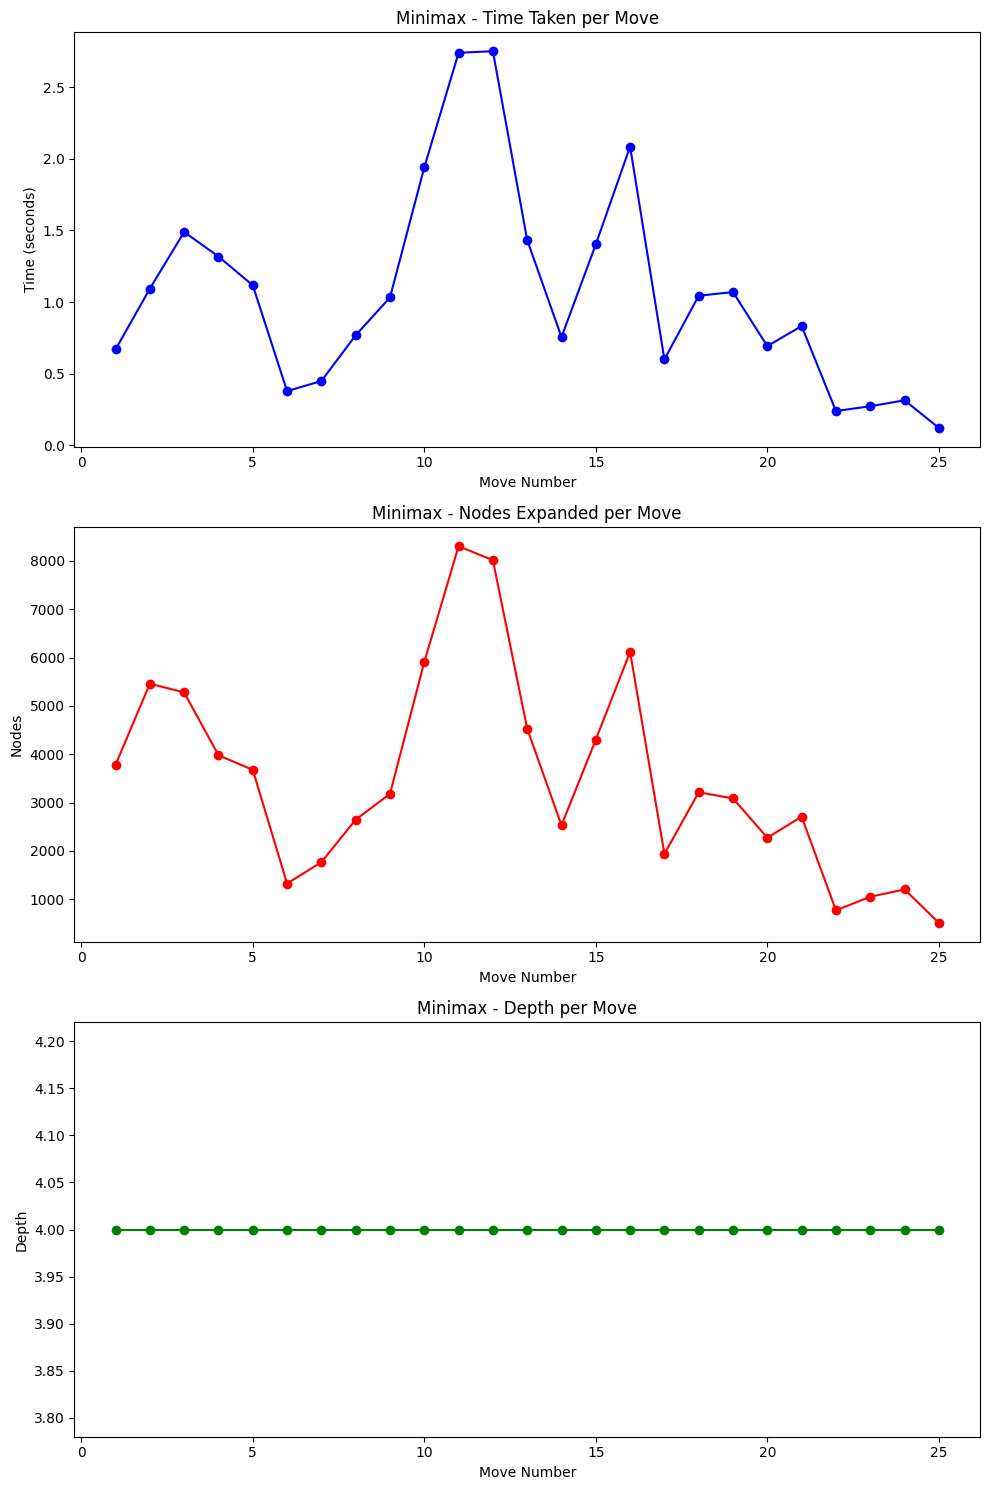


Starting Alpha-Beta Game...
AI (Alpha-Beta) Move 1: Time taken: 0.0466s, Nodes expanded: 267, Depth: 4
AI (Alpha-Beta) Move 2: Time taken: 0.0750s, Nodes expanded: 446, Depth: 4
AI (Alpha-Beta) Move 3: Time taken: 0.0994s, Nodes expanded: 491, Depth: 4
AI (Alpha-Beta) Move 4: Time taken: 0.0556s, Nodes expanded: 342, Depth: 4
AI (Alpha-Beta) Move 5: Time taken: 0.1086s, Nodes expanded: 624, Depth: 4
AI (Alpha-Beta) Move 6: Time taken: 0.1171s, Nodes expanded: 718, Depth: 4
AI (Alpha-Beta) Move 7: Time taken: 0.1824s, Nodes expanded: 734, Depth: 4
AI (Alpha-Beta) Move 8: Time taken: 0.1574s, Nodes expanded: 901, Depth: 4
AI (Alpha-Beta) Move 9: Time taken: 0.1215s, Nodes expanded: 720, Depth: 4
AI (Alpha-Beta) Move 10: Time taken: 0.0410s, Nodes expanded: 260, Depth: 4
AI (Alpha-Beta) Move 11: Time taken: 0.0947s, Nodes expanded: 502, Depth: 4
AI (Alpha-Beta) Move 12: Time taken: 0.1122s, Nodes expanded: 655, Depth: 4
AI (Alpha-Beta) Move 13: Time taken: 0.0844s, Nodes expanded: 514, D

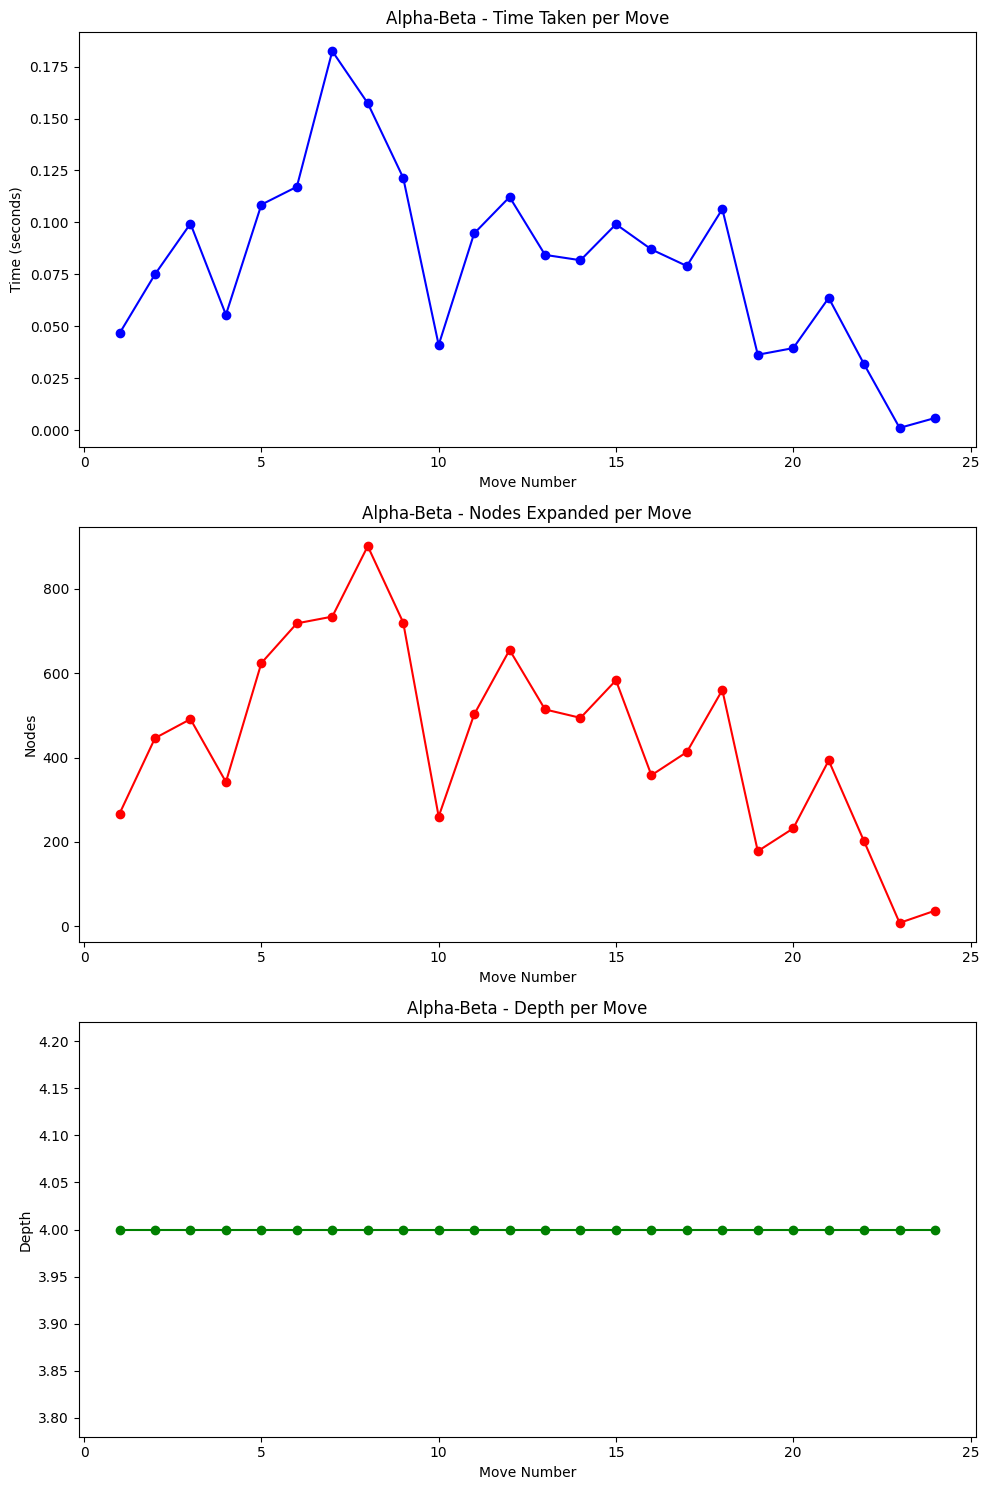

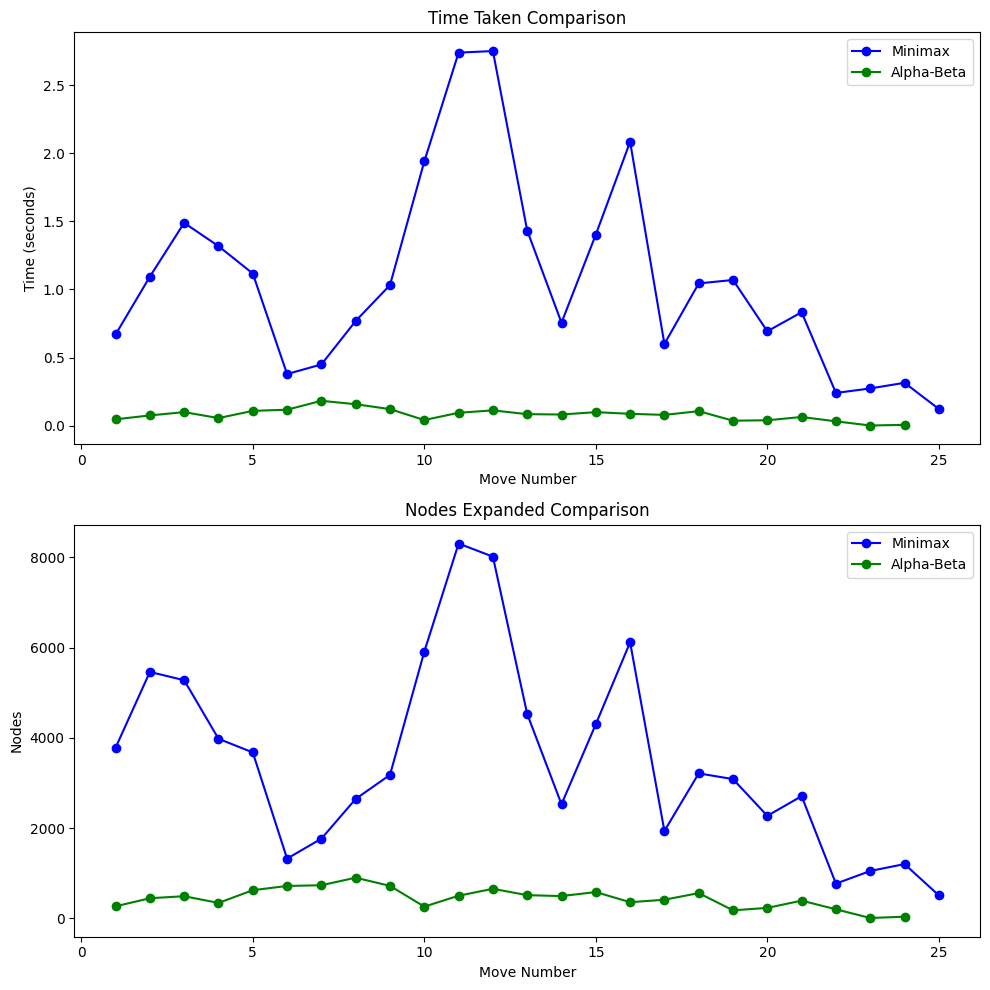

SystemExit: 

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [1]:
import numpy as np
import pygame
import sys
import time
import matplotlib.pyplot as plt

# Initialize pygame
pygame.init()

# Constants for graphics
WIDTH, HEIGHT = 600, 600
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (255, 0, 0)
BLUE = (0, 0, 255)
CELL_SIZE = WIDTH // 8
KING_RED = (200, 0, 0)
KING_BLUE = (0, 0, 200)

class Checkers:
    def __init__(self, use_alpha_beta=False):
        self.board = self.create_board()
        self.window = pygame.display.set_mode((WIDTH, HEIGHT))
        self.use_alpha_beta = use_alpha_beta
        caption = "Checkers - Human (Red) vs AI (Blue) - " + ("Alpha-Beta" if use_alpha_beta else "Minimax")
        pygame.display.set_caption(caption)
        self.selected_piece = None
        self.current_player = 'R'
        self.depth_limit = 4
        self.draw_board()
        self.move_history = []
        self.ai_metrics = [] # (time_taken, nodes_expanded, depth)

    def create_board(self):
        board = np.full((8, 8), '-')
        for row in range(3):
            for col in range(8):
                if (row + col) % 2 == 1:
                    board[row][col] = 'B'
        for row in range(5, 8):
            for col in range(8):
                if (row + col) % 2 == 1:
                    board[row][col] = 'R'
        return board

    def draw_board(self):
        self.window.fill(WHITE)
        for row in range(8):
            for col in range(8):
                color = BLACK if (row + col) % 2 == 0 else WHITE
                pygame.draw.rect(self.window, color, (col * CELL_SIZE, row * CELL_SIZE, CELL_SIZE, CELL_SIZE))
                piece = self.board[row][col]
                if piece in ['R', 'B']:
                    pygame.draw.circle(self.window, RED if piece == 'R' else BLUE,
                                     (col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2),
                                     CELL_SIZE // 2 - 5)
                elif piece in ['RK', 'BK']:
                    pygame.draw.circle(self.window, KING_RED if piece == 'RK' else KING_BLUE,
                                     (col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2),
                                     CELL_SIZE // 2 - 5)
        pygame.display.update()

    def valid_moves(self, row, col):
        moves = []
        piece = self.board[row][col]
        directions = [(-1, -1), (-1, 1)] if piece == 'R' else \
                    [(1, -1), (1, 1)] if piece == 'B' else \
                    [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        for drow, dcol in directions:
            new_row, new_col = row + drow, col + dcol
            if 0 <= new_row < 8 and 0 <= new_col < 8:
                if self.board[new_row][new_col] == '-':
                    moves.append((new_row, new_col))
                elif self.board[new_row][new_col][0] != piece[0]:
                    jump_row, jump_col = new_row + drow, new_col + dcol
                    if 0 <= jump_row < 8 and 0 <= jump_col < 8 and self.board[jump_row][jump_col] == '-':
                        moves.append((jump_row, jump_col))
        return moves

    def get_all_moves(self, player):
        moves = []
        for row in range(8):
            for col in range(8):
                if self.board[row][col] in [player, player + 'K']:
                    valid = self.valid_moves(row, col)
                    for new_row, new_col in valid:
                        moves.append(((row, col), (new_row, new_col)))
        return moves

    def make_move(self, move):
        old_pos, new_pos = move
        old_row, old_col = old_pos
        new_row, new_col = new_pos
        piece = self.board[old_row][old_col]
        self.board[new_row][new_col] = piece
        self.board[old_row][old_col] = '-'
        if abs(new_row - old_row) == 2:
            mid_row, mid_col = (new_row + old_row) // 2, (new_col + old_col) // 2
            self.board[mid_row][mid_col] = '-'
        if new_row == 0 and piece == 'R':
            self.board[new_row][new_col] = 'RK'
        elif new_row == 7 and piece == 'B':
            self.board[new_row][new_col] = 'BK'
        self.move_history.append((self.current_player, move))

    def undo_move(self, move, captured_piece=None):
        old_pos, new_pos = move
        old_row, old_col = old_pos
        new_row, new_col = new_pos
        self.board[old_row][old_col] = self.board[new_row][new_col]
        self.board[new_row][new_col] = '-'
        if captured_piece:
            mid_row, mid_col = (new_row + old_row) // 2, (new_col + old_col) // 2
            self.board[mid_row][mid_col] = captured_piece

    def evaluate(self):
        red_score = sum(1 for row in self.board for p in row if p == 'R') + \
                   sum(2 for row in self.board for p in row if p == 'RK')
        blue_score = sum(1 for row in self.board for p in row if p == 'B') + \
                    sum(2 for row in self.board for p in row if p == 'BK')
        return blue_score - red_score

    def minimax(self, depth, maximizing_player, nodes_expanded=[0]):
        nodes_expanded[0] += 1
        if depth == 0 or self.is_game_over():
            return self.evaluate(), None
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            for move in self.get_all_moves('B'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.minimax(depth - 1, False, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            for move in self.get_all_moves('R'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.minimax(depth - 1, True, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
            return min_eval, best_move

    def alpha_beta(self, depth, maximizing_player, alpha=float('-inf'), beta=float('inf'), nodes_expanded=[0]):
        nodes_expanded[0] += 1
        if depth == 0 or self.is_game_over():
            return self.evaluate(), None
        if maximizing_player:
            max_eval = float('-inf')
            best_move = None
            for move in self.get_all_moves('B'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.alpha_beta(depth - 1, False, alpha, beta, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score > max_eval:
                    max_eval = eval_score
                    best_move = move
                alpha = max(alpha, eval_score)
                if beta <= alpha:
                    break # Beta cutoff
            return max_eval, best_move
        else:
            min_eval = float('inf')
            best_move = None
            for move in self.get_all_moves('R'):
                captured = None
                if abs(move[0][0] - move[1][0]) == 2:
                    mid_row, mid_col = (move[0][0] + move[1][0]) // 2, (move[0][1] + move[1][1]) // 2
                    captured = self.board[mid_row][mid_col]
                self.make_move(move)
                eval_score, _ = self.alpha_beta(depth - 1, True, alpha, beta, nodes_expanded)
                self.undo_move(move, captured)
                if eval_score < min_eval:
                    min_eval = eval_score
                    best_move = move
                beta = min(beta, eval_score)
                if beta <= alpha:
                    break # Alpha cutoff
            return min_eval, best_move

    def is_game_over(self):
        return not any('B' in row for row in self.board) or not any('R' in row for row in self.board)

    def ai_move(self):
        if self.get_all_moves('B'):
            start_time = time.time()
            nodes_expanded = [0]
            if self.use_alpha_beta:
                _, move = self.alpha_beta(self.depth_limit, True, nodes_expanded=nodes_expanded)
            else:
                _, move = self.minimax(self.depth_limit, True, nodes_expanded)
            end_time = time.time()
            time_taken = end_time - start_time
            self.ai_metrics.append((time_taken, nodes_expanded[0], self.depth_limit))
            algo_name = "Alpha-Beta" if self.use_alpha_beta else "Minimax"
            print(f"AI ({algo_name}) Move {len(self.ai_metrics)}: Time taken: {time_taken:.4f}s, "
                  f"Nodes expanded: {nodes_expanded[0]}, Depth: {self.depth_limit}")
            if move:
                self.make_move(move)
                self.current_player = 'R'
                self.draw_board()

    def human_move(self, row, col):
        if self.selected_piece:
            old_row, old_col = self.selected_piece
            if (row, col) in self.valid_moves(old_row, old_col):
                move = ((old_row, old_col), (row, col))
                self.make_move(move)
                self.current_player = 'B'
                self.selected_piece = None
                self.draw_board()
                return True
            self.selected_piece = None
        else:
            if self.board[row][col] in ['R', 'RK']:
                self.selected_piece = (row, col)
        return False

    def visualize_metrics(self, title):
        if not self.ai_metrics:
            print(f"No AI moves to visualize for {title}.")
            return
        moves = range(1, len(self.ai_metrics) + 1)
        times = [m[0] for m in self.ai_metrics]
        nodes = [m[1] for m in self.ai_metrics]
        depths = [m[2] for m in self.ai_metrics]
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 15))
        ax1.plot(moves, times, 'b-o')
        ax1.set_title(f'{title} - Time Taken per Move')
        ax1.set_xlabel('Move Number')
        ax1.set_ylabel('Time (seconds)')
        
        ax2.plot(moves, nodes, 'r-o')
        ax2.set_title(f'{title} - Nodes Expanded per Move')
        ax2.set_xlabel('Move Number')
        ax2.set_ylabel('Nodes')
        
        ax3.plot(moves, depths, 'g-o')
        ax3.set_title(f'{title} - Depth per Move')
        ax3.set_xlabel('Move Number')
        ax3.set_ylabel('Depth')
        
        plt.tight_layout()
        plt.show()
        return times, nodes, depths

def run_game(use_alpha_beta):
    game = Checkers(use_alpha_beta)
    running = True
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.MOUSEBUTTONDOWN and game.current_player == 'R':
                x, y = event.pos
                row, col = y // CELL_SIZE, x // CELL_SIZE
                if game.human_move(row, col):
                    pygame.time.wait(500)
                    if not game.is_game_over():
                        game.ai_move()
                    if game.is_game_over():
                        winner = "Human (Red)" if not any('B' in row for row in game.board) else "AI (Blue)"
                        print(f"Game Over! {winner} wins!")
                        running = False
        pygame.display.flip()
    metrics = game.visualize_metrics("Alpha-Beta" if use_alpha_beta else "Minimax")
    pygame.time.wait(2000)
    return metrics

def compare_algorithms(minimax_metrics, alpha_beta_metrics):
    minimax_times, minimax_nodes, _ = minimax_metrics
    alpha_beta_times, alpha_beta_nodes, _ = alpha_beta_metrics
    moves_minimax = range(1, len(minimax_times) + 1)
    moves_alpha_beta = range(1, len(alpha_beta_times) + 1)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    ax1.plot(moves_minimax, minimax_times, 'b-o', label='Minimax')
    ax1.plot(moves_alpha_beta, alpha_beta_times, 'g-o', label='Alpha-Beta')
    ax1.set_title('Time Taken Comparison')
    ax1.set_xlabel('Move Number')
    ax1.set_ylabel('Time (seconds)')
    ax1.legend()
    
    ax2.plot(moves_minimax, minimax_nodes, 'b-o', label='Minimax')
    ax2.plot(moves_alpha_beta, alpha_beta_nodes, 'g-o', label='Alpha-Beta')
    ax2.set_title('Nodes Expanded Comparison')
    ax2.set_xlabel('Move Number')
    ax2.set_ylabel('Nodes')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Run Minimax game
    print("Starting Minimax Game...")
    minimax_metrics = run_game(use_alpha_beta=False)
    
    # Reset pygame for the second game
    pygame.quit()
    pygame.init()
    
    # Run Alpha-Beta game
    print("\nStarting Alpha-Beta Game...")
    alpha_beta_metrics = run_game(use_alpha_beta=True)
    
    # Compare the two algorithms
    compare_algorithms(minimax_metrics, alpha_beta_metrics)
    pygame.quit()
    sys.exit()